In [1]:
# Setup: put src/ on the path so the notebook runs from any working directory.
import os, sys
_p = os.getcwd()
while _p != os.path.dirname(_p):
    if os.path.isdir(os.path.join(_p, "src")):
        sys.path.insert(0, os.path.join(_p, "src"))
        break
    _p = os.path.dirname(_p)

#import libraries
import json
import time
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


In [2]:
# import functions
from data_load import load_data_for_modeling
from stop_words import get_stop_words
from embedding import load_sentence_embedding_model, generate_embeddings

from bertopic_components import BERTopicConfig, run_bertopic, set_seed, SEED

from performance_index_bertopic import (build_tokeniser,build_summary_table,build_jaccard_matrix,)

from config import BASE_DATA_FOLDER


/home/s215005/traffic_project/Thesis-traffic-safety/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# set up paths and results directories
RESULTS_DIR_UMAP = Path("bertopic_results/hyperparameter_tuning/phase_1")
RESULTS_DIR_UMAP.mkdir(parents=True, exist_ok=True)

RESULTS_DIR_hdbscan = Path("bertopic_results/hyperparameter_tuning/phase_2")
RESULTS_DIR_hdbscan.mkdir(parents=True, exist_ok=True)

In [4]:
# set seed for reproducibility
set_seed()

In [5]:
# get stop words using the repository default
danish_stop_words = get_stop_words()


In [6]:
# Everything fixed across the all runs lives in base_cfg.
base_cfg = dict(
    mode="unsupervised",
    n_components=10,
    min_dist=0.01,
    umap_metric="cosine",
    min_cluster_size=100,
    min_samples=10,
    stop_words=danish_stop_words,
    seed=SEED,
)

In [7]:
# load data
data = load_data_for_modeling(
    data_folder=BASE_DATA_FOLDER,
    #subset_size=100000,   # optional
    encode_labels=False,
    verbose=True,
)

df = data["df"]
docs = data["docs"]
labels = data["labels"]


Loading all Excel files...
Loading: raw_1985_v1.xlsx
Loading: raw_1986-1995_v1.xlsx
Loading: raw_1996-2005_v1.xlsx
Loading: raw_2006-2015_v1.xlsx
Loading: raw_2016-2026_v1.xlsx
Combined dataset shape: (898677, 6)
After cleaning: (890540, 8)

Total documents for modeling: 890540
Unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [8]:
#embeddings
MODEL_NAME = "KennethTM/MiniLM-L6-danish-encoder"

embedding_model = load_sentence_embedding_model(MODEL_NAME)

embeddings = generate_embeddings(
    docs=docs,
    embedding_model=embedding_model,
    batch_size=64,
    verbose=True,
)



Loading embedding model...
Loaded embedding model: KennethTM/MiniLM-L6-danish-encoder
Generating document embeddings...
(This may take a few minutes depending on dataset size)


Batches: 100%|██████████| 13915/13915 [03:19<00:00, 69.61it/s] 


Embedding shape: (890540, 384)


# Phase 1

## min distance

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. Define the sweep — min_dist range between 0.0 and 0.1
# ══════════════════════════════════════════════════════════════════════════════
 
MIN_DIST_SWEEP = [0.0, 0.01, 0.02, 0.05, 0.07, 0.1]



In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. Run the sweep
# ══════════════════════════════════════════════════════════════════════════════

umap_results_md = []

for min_dist in MIN_DIST_SWEEP:
    label     = f"md{str(min_dist).replace('.', '')}"   # e.g. md001, md01, md1
    cache_dir = RESULTS_DIR_UMAP / label
    cache_dir.mkdir(exist_ok=True)
    cache_res = cache_dir / "result.json"

    print(f"\n{'='*55}")
    print(f"min_dist = {min_dist}")
    print(f"{'='*55}")

    # ── Load from cache if available ──
    if cache_res.exists():
        print("  → Cache found, skipping recompute.")
        with open(cache_res) as f:
            result = json.load(f)
        umap_results_md.append(result)
        print(f"  → {result['n_clusters']} clusters | "
              f"{result['noise_pct']}% noise | DBCV: {result['dbcv']}")
        continue

    # ── Build config and run ──
    cfg = BERTopicConfig(
        n_neighbors=50,       # fixed at baseline from Phase 1
        min_dist=min_dist,
        **{k: v for k, v in base_cfg.items() if k != "min_dist"},
    )
    model, topics, probs = run_bertopic(cfg, docs, embeddings, embedding_model)
        # ── Build config and run ──
 
    # ── Extract cluster stats from the fitted model ──
    cluster_labels = np.array(model.hdbscan_model.labels_)
    mask           = cluster_labels != -1
    n_topics_before = len(set(cluster_labels[mask]))
    n_topics_after  = model.get_topic_info().shape[0] - 1  # excludes outlier topic (-1)
   # n_clusters     = len(set(cluster_labels[mask]))
    noise_pct      = round(100 * (~mask).sum() / len(cluster_labels), 1)
    dbcv           = round(float(model.hdbscan_model.relative_validity_), 4)

    print(f"  → {n_topics_before} clusters | {noise_pct}% noise | DBCV: {dbcv}")

    # ── Persist result ──
    result = {
    **cfg.to_dict(),
    "n_topics_before":  n_topics_before,
    "n_topics_after":   n_topics_after,
    "noise_pct":        noise_pct,
    "dbcv":             dbcv,
    }   
    
    with open(cache_res, "w") as f:
        json.dump(result, f)
    umap_results_md.append(result)

print("\n✓ min_dist sweep complete")


2026-04-22 11:32:22,096 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



min_dist = 0.0


2026-04-22 11:34:37,655 - BERTopic - Dimensionality - Completed ✓
2026-04-22 11:34:37,657 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 11:34:45,291 - BERTopic - Cluster - Completed ✓
2026-04-22 11:34:45,292 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-22 11:34:49,723 - BERTopic - Representation - Completed ✓
2026-04-22 11:34:49,726 - BERTopic - Topic reduction - Reducing number of topics
2026-04-22 11:34:49,752 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 11:34:54,687 - BERTopic - Representation - Completed ✓
2026-04-22 11:34:54,705 - BERTopic - Topic reduction - Reduced number of topics from 58 to 15
2026-04-22 11:34:57,661 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


  → 57 clusters | 48.1% noise | DBCV: 0.1536

min_dist = 0.01


2026-04-22 11:37:10,240 - BERTopic - Dimensionality - Completed ✓
2026-04-22 11:37:10,243 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 11:37:17,488 - BERTopic - Cluster - Completed ✓
2026-04-22 11:37:17,489 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-22 11:37:21,441 - BERTopic - Representation - Completed ✓
2026-04-22 11:37:21,443 - BERTopic - Topic reduction - Reducing number of topics
2026-04-22 11:37:21,463 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 11:37:25,276 - BERTopic - Representation - Completed ✓
2026-04-22 11:37:25,282 - BERTopic - Topic reduction - Reduced number of topics from 18 to 10
2026-04-22 11:37:28,024 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


...

  → 56 clusters | 51.0% noise | DBCV: 0.2585

min_dist = 0.07


2026-04-22 11:44:50,461 - BERTopic - Dimensionality - Completed ✓
2026-04-22 11:44:50,464 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 11:44:58,537 - BERTopic - Cluster - Completed ✓
2026-04-22 11:44:58,538 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-22 11:45:02,501 - BERTopic - Representation - Completed ✓
2026-04-22 11:45:02,508 - BERTopic - Topic reduction - Reducing number of topics
2026-04-22 11:45:02,527 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 11:45:06,228 - BERTopic - Representation - Completed ✓
2026-04-22 11:45:06,239 - BERTopic - Topic reduction - Reduced number of topics from 10 to 4
2026-04-22 11:45:08,987 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


  → 9 clusters | 0.2% noise | DBCV: 0.1905

min_dist = 0.1


2026-04-22 11:47:20,829 - BERTopic - Dimensionality - Completed ✓
2026-04-22 11:47:20,831 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 11:47:29,061 - BERTopic - Cluster - Completed ✓
2026-04-22 11:47:29,062 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-22 11:47:33,061 - BERTopic - Representation - Completed ✓
2026-04-22 11:47:33,068 - BERTopic - Topic reduction - Reducing number of topics
2026-04-22 11:47:33,088 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 11:47:36,796 - BERTopic - Representation - Completed ✓
2026-04-22 11:47:36,808 - BERTopic - Topic reduction - Reduced number of topics from 10 to 4


  → 9 clusters | 0.3% noise | DBCV: 0.3948

✓ min_dist sweep complete


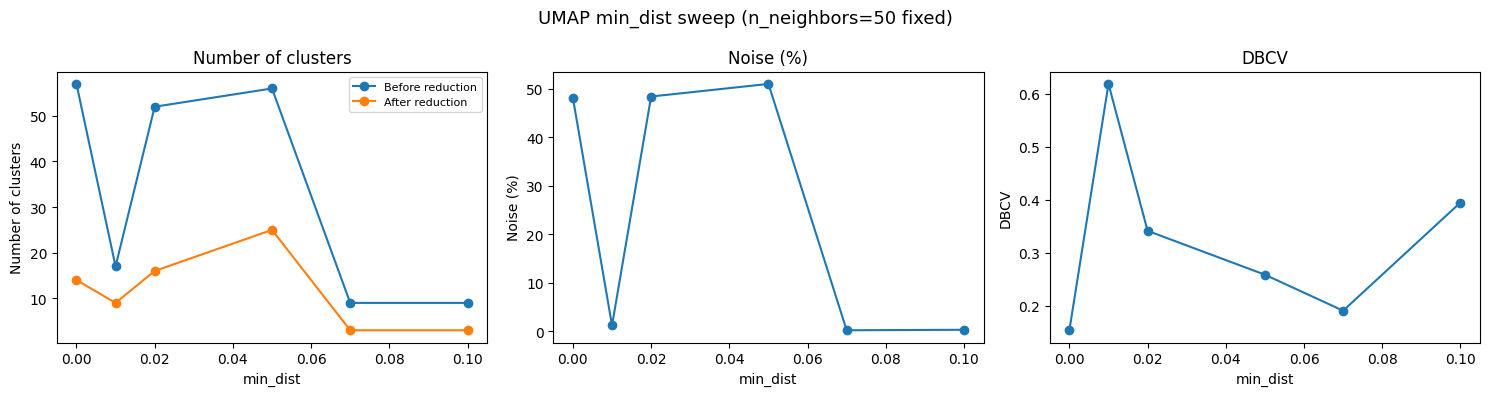

Saved → bertopic_results/hyperparameter_tuning/phase_1/min_dist_sweep.png


In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. Plot
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = [r["min_dist"] for r in umap_results_md]

for ax, (key, ylabel) in zip(axes, [
    ("n_topics_before", "Number of clusters"),
    ("noise_pct",       "Noise (%)"),
    ("dbcv",            "DBCV"),
]):
    if key == "n_topics_before":
        ax.plot(x, [r["n_topics_before"] for r in umap_results_md], marker="o", label="Before reduction")
        ax.plot(x, [r["n_topics_after"]  for r in umap_results_md], marker="o", label="After reduction")
        ax.legend(fontsize=8)
    else:
        ax.plot(x, [r[key] for r in umap_results_md], marker="o")

    ax.set_xlabel("min_dist")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

plt.suptitle("UMAP min_dist sweep (n_neighbors=50 fixed)", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR_UMAP / "min_dist_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR_UMAP / 'min_dist_sweep.png'}")

## n_Neighbors 

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. Define the sweep — only what changes across runs
# ══════════════════════════════════════════════════════════════════════════════
 
N_NEIGHBORS_SWEEP = [30, 50, 75, 100, 150, 200]
 

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. Run the sweep
# ══════════════════════════════════════════════════════════════════════════════
 
umap_results = []
 
for n_neighbors in N_NEIGHBORS_SWEEP:
    label     = f"nn{n_neighbors}"
    cache_dir = RESULTS_DIR_UMAP / label
    cache_dir.mkdir(exist_ok=True)
    cache_res = cache_dir / "result.json"
 
    print(f"\n{'='*55}")
    print(f"n_neighbors = {n_neighbors}")
    print(f"{'='*55}")
 
    # ── Load from cache if available ──
    if cache_res.exists():
        print("  → Cache found, skipping recompute.")
        with open(cache_res) as f:
            result = json.load(f)
        umap_results.append(result)
        print(f"  → {result['n_clusters']} clusters | "
              f"{result['noise_pct']}% noise | DBCV: {result['dbcv']}")
        continue
 
    # ── Build config and run ──
    cfg = BERTopicConfig(n_neighbors=n_neighbors, **base_cfg)
    model, topics, probs = run_bertopic(cfg, docs, embeddings, embedding_model)
 
    # ── Extract cluster stats from the fitted model ──
    cluster_labels = np.array(model.hdbscan_model_.labels_)
    mask           = cluster_labels != -1
    n_clusters     = len(set(cluster_labels[mask]))
    noise_pct      = round(100 * (~mask).sum() / len(cluster_labels), 1)
    dbcv           = round(float(model.hdbscan_model_.relative_validity_), 4)
 
    print(f"  → {n_clusters} clusters | {noise_pct}% noise | DBCV: {dbcv}")
 
    # ── Persist result ──
    result = {**cfg.to_dict(), "n_clusters": n_clusters, "noise_pct": noise_pct, "dbcv": dbcv}
    with open(cache_res, "w") as f:
        json.dump(result, f)
    umap_results.append(result)
 
print("\n✓ Sweep complete")



n_neighbors = 30
  → Cache found, skipping recompute.
  → 339 clusters | 47.7% noise | DBCV: 0.3047

n_neighbors = 50
  → Cache found, skipping recompute.
  → 316 clusters | 49.6% noise | DBCV: 0.2984

n_neighbors = 75
  → Cache found, skipping recompute.
  → 300 clusters | 49.3% noise | DBCV: 0.2937

n_neighbors = 100
  → Cache found, skipping recompute.
  → 278 clusters | 48.1% noise | DBCV: 0.1521

n_neighbors = 150
  → Cache found, skipping recompute.
  → 278 clusters | 53.3% noise | DBCV: 0.1127

n_neighbors = 200
  → Cache found, skipping recompute.
  → 271 clusters | 53.3% noise | DBCV: 0.1273

✓ Sweep complete


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. Summary table
# ══════════════════════════════════════════════════════════════════════════════
 
print(f"\n{'n_neighbors':>12} {'n_clusters':>12} {'noise_pct':>10} {'dbcv':>8}")
print("-" * 46)
for r in umap_results:
    print(f"{r['n_neighbors']:>12} {r['n_clusters']:>12} {r['noise_pct']:>10} {r['dbcv']:>8}")


 n_neighbors   n_clusters  noise_pct     dbcv
----------------------------------------------
          30          339       47.7   0.3047
          50          316       49.6   0.2984
          75          300       49.3   0.2937
         100          278       48.1   0.1521
         150          278       53.3   0.1127
         200          271       53.3   0.1273


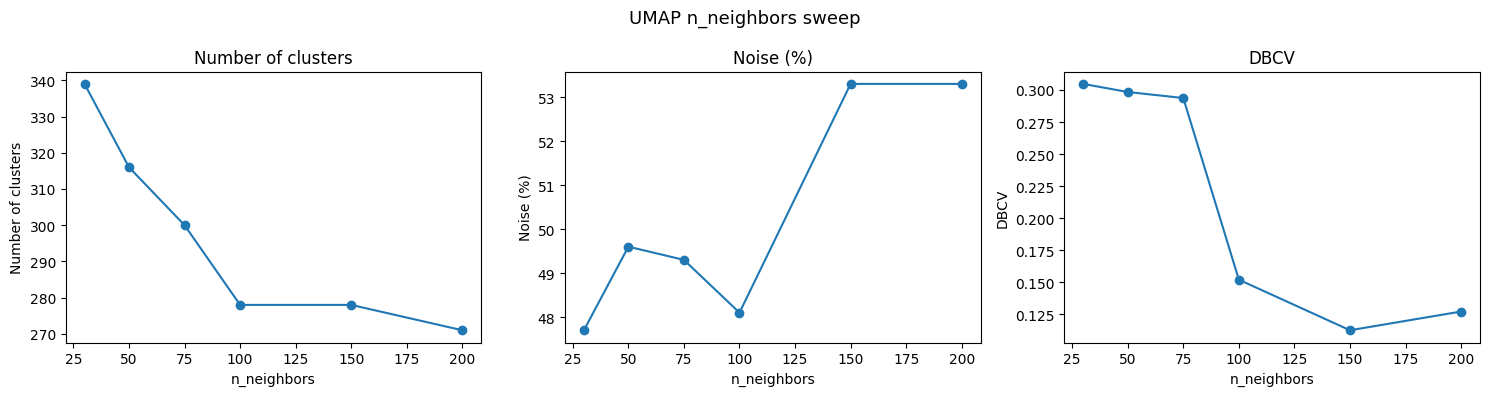

Saved → bertopic_results/hyperparameter_tuning/phase_1/umap_sweep.png


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. Plot
# ══════════════════════════════════════════════════════════════════════════════
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
x = [r["n_neighbors"] for r in umap_results]
 
for ax, (key, ylabel) in zip(axes, [
    ("n_clusters", "Number of clusters"),
    ("noise_pct",  "Noise (%)"),
    ("dbcv",       "DBCV"),
]):
    ax.plot(x, [r[key] for r in umap_results], marker="o")
    ax.set_xlabel("n_neighbors")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
 
plt.suptitle("UMAP n_neighbors sweep", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR_UMAP / "umap_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR_UMAP / 'umap_sweep.png'}")


# Phase 2

In [9]:
param_grid = [
    # --- n_components=10 (existing — cache will be reused) ---
    #{"min_cluster_size": 900,  "n_neighbors": 50, "min_samples": 10, "n_components": 10, "label": "mcs900_nn50_ms10"},
    #{"min_cluster_size": 630,  "n_neighbors": 50, "min_samples": 10, "n_components": 10, "label": "mcs630_nn50_ms10"},
    #{"min_cluster_size": 1170, "n_neighbors": 50, "min_samples": 10, "n_components": 10, "label": "mcs1170_nn50_ms10"},
    #{"min_cluster_size": 900,  "n_neighbors": 35, "min_samples": 10, "n_components": 10, "label": "mcs900_nn35_ms10"},
    {"min_cluster_size": 900,  "n_neighbors": 65, "min_samples": 10, "n_components": 10, "label": "mcs900_nn65_ms10"},
    #{"min_cluster_size": 900,  "n_neighbors": 50, "min_samples":  7, "n_components": 10, "label": "mcs900_nn50_ms7"},
    #{"min_cluster_size": 900,  "n_neighbors": 50, "min_samples": 13, "n_components": 10, "label": "mcs900_nn50_ms13"},

    # --- n_components=5 (new) ---
    #{"min_cluster_size": 900,  "n_neighbors": 50, "min_samples": 10, "n_components": 5, "label": "mcs900_nn50_ms10_nc5"},
    #{"min_cluster_size": 630,  "n_neighbors": 50, "min_samples": 10, "n_components": 5, "label": "mcs630_nn50_ms10_nc5"},
    #{"min_cluster_size": 1170, "n_neighbors": 50, "min_samples": 10, "n_components": 5, "label": "mcs1170_nn50_ms10_nc5"},
    #{"min_cluster_size": 900,  "n_neighbors": 35, "min_samples": 10, "n_components": 5, "label": "mcs900_nn35_ms10_nc5"},
    {"min_cluster_size": 900,  "n_neighbors": 65, "min_samples": 10, "n_components": 5, "label": "mcs900_nn65_ms10_nc5"},
   # {"min_cluster_size": 900,  "n_neighbors": 50, "min_samples":  7, "n_components": 5, "label": "mcs900_nn50_ms7_nc5"},
   # {"min_cluster_size": 900,  "n_neighbors": 50, "min_samples": 13, "n_components": 5, "label": "mcs900_nn50_ms13_nc5"},
]

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. Run the grid
# ══════════════════════════════════════════════════════════════════════════════

results = {}

for p in param_grid:
    label = p["label"]
    print(f"\n{'='*55}")
    print(f"Running: {label}  |  mcs={p['min_cluster_size']}  nn={p['n_neighbors']}  ms={p['min_samples']}")
    print(f"{'='*55}")
    

    p_clean = {k: v for k, v in p.items() if k != "label"}
    cfg     = BERTopicConfig(**{**base_cfg, **p_clean})
    print(cfg)

    t0 = time.time()
    model, topics, probs = run_bertopic(cfg, docs, embeddings, embedding_model)
    elapsed = time.time() - t0

    # Extract top-10 keywords per topic as sets (for Jaccard later)
    topic_keywords = {
        tid: set(w for w, _ in model.get_topic(tid)[:10])
        for tid in model.get_topics()
        if tid != -1
    }

    n_topics    = len(topic_keywords)
    outlier_pct = 100 * sum(1 for t in topics if t == -1) / len(topics)

    print(f"  → {n_topics} topics | {outlier_pct:.1f}% outliers | {elapsed:.0f}s")

    results[label] = {
        "params":      cfg.to_dict(),   # full config, not just the three params
        "keywords":    topic_keywords,
        "n_topics":    n_topics,
        "outlier_pct": outlier_pct,
        "elapsed_s":   elapsed,
        "dbcv":      round(float(model.hdbscan_model.relative_validity_), 4),
    }
    results_df = pd.DataFrame.from_dict(results, orient="index")
    results_df.to_csv(RESULTS_DIR_hdbscan / "phase_2_results_part4.csv")
    print(f"\nSaved → {RESULTS_DIR_hdbscan / 'phase_2_results_part4.csv'}")



Running: mcs900_nn65_ms10  |  mcs=900  nn=65  ms=10
BERTopicConfig(mode='unsupervised', n_neighbors=65, n_components=10, min_dist=0.01, umap_metric='cosine', min_cluster_size=900, min_samples=10, hdbscan_metric='euclidean', cluster_selection_method='eom', gen_min_span_tree=True, prediction_data=True, stop_words=['P1', 'P2', 'P3', 'Part 1', 'Part 2', 'Part 3', 'ad', 'af', 'akkurat', 'al', 'aldrig', 'alene', 'alle', 'allerede', 'alligevel', 'alt', 'altid', 'altså', 'anden', 'andet', 'andre', 'anm', 'anmeldte', 'art', 'at', 'bag', 'bare', 'begge', 'bil', 'bilen', 'bl.a.', 'blandt', 'blev', 'blive', 'bliver', 'blot', 'bmw', 'bringe', 'brug', 'burde', 'både', 'bør', 'ca', 'ca.', 'da', 'dag', 'de', 'del', 'dem', 'den', 'denne', 'dens', 'der', 'derefter', 'deres', 'derfor', 'derfra', 'deri', 'dermed', 'derpå', 'derved', 'des', 'desto', 'det', 'dets', 'dette', 'dig', 'din', 'dine', 'disse', 'dit', 'dog', 'du', 'dér', 'dét', 'efter', 'efterfølgende', 'egen', 'ej', 'eller', 'ellers', 'en', 'end

2026-04-22 13:38:51,669 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-22 14:51:02,948 - BERTopic - Dimensionality - Completed ✓
2026-04-22 14:51:02,972 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 14:54:56,716 - BERTopic - Cluster - Completed ✓
2026-04-22 14:54:56,717 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-22 14:55:29,279 - BERTopic - Representation - Completed ✓
2026-04-22 14:55:29,311 - BERTopic - Topic reduction - Reducing number of topics
2026-04-22 14:55:29,471 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 14:56:05,007 - BERTopic - Representation - Completed ✓
2026-04-22 14:56:05,114 - BERTopic - Topic reduction - Reduced number of topics from 59 to 26


  → 25 topics | 45.2% outliers | 4634s

Saved → bertopic_results/hyperparameter_tuning/phase_2/phase_2_results_part4.csv

Running: mcs900_nn65_ms10_nc5  |  mcs=900  nn=65  ms=10
BERTopicConfig(mode='unsupervised', n_neighbors=65, n_components=5, min_dist=0.01, umap_metric='cosine', min_cluster_size=900, min_samples=10, hdbscan_metric='euclidean', cluster_selection_method='eom', gen_min_span_tree=True, prediction_data=True, stop_words=['P1', 'P2', 'P3', 'Part 1', 'Part 2', 'Part 3', 'ad', 'af', 'akkurat', 'al', 'aldrig', 'alene', 'alle', 'allerede', 'alligevel', 'alt', 'altid', 'altså', 'anden', 'andet', 'andre', 'anm', 'anmeldte', 'art', 'at', 'bag', 'bare', 'begge', 'bil', 'bilen', 'bl.a.', 'blandt', 'blev', 'blive', 'bliver', 'blot', 'bmw', 'bringe', 'brug', 'burde', 'både', 'bør', 'ca', 'ca.', 'da', 'dag', 'de', 'del', 'dem', 'den', 'denne', 'dens', 'der', 'derefter', 'deres', 'derfor', 'derfra', 'deri', 'dermed', 'derpå', 'derved', 'des', 'desto', 'det', 'dets', 'dette', 'dig', 'di

2026-04-22 14:56:30,150 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-22 15:51:12,174 - BERTopic - Dimensionality - Completed ✓
2026-04-22 15:51:12,185 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 15:53:01,863 - BERTopic - Cluster - Completed ✓
2026-04-22 15:53:01,864 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-22 15:53:36,484 - BERTopic - Representation - Completed ✓
2026-04-22 15:53:36,517 - BERTopic - Topic reduction - Reducing number of topics
2026-04-22 15:53:36,677 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 15:54:11,809 - BERTopic - Representation - Completed ✓
2026-04-22 15:54:11,910 - BERTopic - Topic reduction - Reduced number of topics from 62 to 14


  → 13 topics | 45.4% outliers | 3463s

Saved → bertopic_results/hyperparameter_tuning/phase_2/phase_2_results_part4.csv


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. Save for further analysis
# ══════════════════════════════════════════════════════════════════════════════

results_df = pd.DataFrame.from_dict(results, orient="index")
results_df.to_csv(RESULTS_DIR_hdbscan / "phase_2_results_part4.csv")
print(f"\nSaved → {RESULTS_DIR_hdbscan / 'phase_2_results_part4.csv'}")



Saved → bertopic_results/hyperparameter_tuning/phase_2/phase_2_results_part4.csv


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. Performance metrics
# ══════════════════════════════════════════════════════════════════════════════

tokenised, dictionary = build_tokeniser(docs, stop_words=danish_stop_words)

summary_df = build_summary_table(results, tokenised, dictionary)
print(summary_df.to_string(index=False))
summary_df.to_csv(RESULTS_DIR_hdbscan / "summary.csv", index=False)

matrix_df = build_jaccard_matrix(results)
matrix_df.to_csv(RESULTS_DIR_hdbscan / "jaccard.csv")

print(f"Saved → {RESULTS_DIR_hdbscan / 'summary.csv'}")
print(f"Saved → {RESULTS_DIR_hdbscan / 'jaccard.csv'}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

                 run  min_cluster_size  n_neighbors  min_samples  n_topics  outlier_pct   dbcv  coherence_cv  diversity
    mcs900_nn65_ms10               900           65           10        25         45.2 0.1993        0.3781     0.9760
mcs900_nn65_ms10_nc5               900           65           10        13         45.4 0.1775        0.3502     0.9615
Saved → bertopic_results/hyperparameter_tuning/phase_2/summary.csv
Saved → bertopic_results/hyperparameter_tuning/phase_2/jaccard.csv
